# Chapter 7: Ontology Design (RDFS / OWL)

**Level 2: Modeling & Querying** · ⏱ about 3 hours · Dataset: *Recipes & Nutrition*

### What you will learn

1. What an **ontology** is and why a knowledge graph needs one
2. How to **discover** the vocabulary your data already uses
3. **RDFS**: classes, subclasses, properties, domain and range, labels
4. **OWL**: object vs datatype properties, inverse, functional and transitive properties, property chains, disjointness, and **defined classes**
5. **Design decisions**: classes or instances, naming, reusing standard vocabularies, what OWL *can't* express
6. **OWL profiles** and what Stardog's reasoner supports
7. **Hands-on:** the Recipes ontology in Turtle (`ontology/recipes.ttl`): load it into its own named graph, check the data against it, generate a data dictionary and a diagram, and register it as a **named model** for Studio and Explorer

Chapter 8 then puts the ontology to work with reasoning.

In [1]:
import sys
from pathlib import Path

SRC = str(Path('..', 'src').resolve())
if SRC not in sys.path:
    sys.path.insert(0, SRC)

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import stardog
from rdflib import Graph

from kg import client, models, sparql

pd.set_option('display.max_colwidth', 80)
conn = client.connect()
PREFIX = 'urn:tutorial:ch07'
DATA_GRAPH, MODEL_GRAPH = f'{PREFIX}:data', f'{PREFIX}:model'
MODEL_NAME = 'RecipeKG'                    # the name shown in Explorer / Studio
ONTOLOGY_FILE = Path('..', 'ontology', 'recipes.ttl')

with client.transaction(conn) as stats:
    conn.clear(graph_uri=DATA_GRAPH)
    conn.add(stardog.content.File(str(Path('..', 'data', 'recipes', 'recipes.ttl'))), graph_uri=DATA_GRAPH)
print('Loaded data:', stats)

PREFIXES = '''PREFIX rec: <http://example.org/recipes#>
PREFIX owl: <http://www.w3.org/2002/07/owl#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX skos: <http://www.w3.org/2004/02/skos/core#>
PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>
'''
def q(query, graphs=DATA_GRAPH, **kwargs):
    return sparql.run_query(conn, PREFIXES + query, graphs=graphs, **kwargs)

def short(iri):
    return str(iri).replace('http://example.org/recipes#', 'rec:').replace('http://www.w3.org/2001/XMLSchema#', 'xsd:') \
                   .replace('http://www.w3.org/2004/02/skos/core#', 'skos:').replace('http://www.w3.org/1999/02/22-rdf-syntax-ns#', 'rdf:')

Loaded data: {'added': 1020, 'removed': 0}


## 7.1 Why an ontology?

Our recipe data works, but its **meaning lives only in our heads and our code**:

- Nothing says `rec:prepMinutes` holds an integer, or that it belongs to recipes.
- Nothing says a category is a kind of taxonomy node, or that `skos:broader` can be followed any number of steps.
- A typo such as `rec:prepMinuts` is silently a new property.
- Tools like Explorer can't show "the model", and the reasoner can't infer anything.

An **ontology** writes that meaning down **as RDF**: the classes of things, the properties that link them, and the rules that connect them. Because it is itself a graph, you query and version it like data.

| | Ontology | Relational schema |
|---|---|---|
| Written in | RDF (RDFS / OWL) | DDL |
| Role of domain/range | **Infer** facts (open world) | **Reject** rows (closed world) |
| Hierarchies | Built in (`subClassOf`, `subPropertyOf`) | Emulated with tables |
| Changes | Add triples, no migration | `ALTER TABLE` |
| Lives | In the graph, next to the data | Outside the data |

> 🔁 **Neo4j equivalent:** Neo4j has no schema language. Labels are like classes but have no hierarchy, and constraints and indexes cover only uniqueness and existence. The neosemantics (n10s) plugin can import OWL, but Neo4j doesn't reason with it.

## 7.2 Discover the vocabulary in use

Good ontologies start from the data. Which classes exist, and how many instances each has?

In [2]:
q('SELECT ?class (COUNT(?s) AS ?instances) { ?s a ?class } GROUP BY ?class ORDER BY DESC(?instances)') \
  .assign(**{'class': lambda d: d['class'].map(short)})

,class,instances
0,rec:IngredientLine,84
1,rec:Ingredient,42
2,rec:Category,28
3,rec:Recipe,14
4,rec:Allergen,14


For every class: which properties do its members use, and what kind of values do they hold? This is a **property profile**, the raw material for domains and ranges:

In [3]:
profile = q('''
SELECT ?subject_type ?property (GROUP_CONCAT(DISTINCT ?kind; separator=", ") AS ?value_kind) (COUNT(*) AS ?uses)
WHERE {
  ?s ?property ?o ; a ?subject_type .
  BIND(IF(isIRI(?o), "IRI", IF(isBlank(?o), "blank node",
       IF(lang(?o) != "", CONCAT("text @", lang(?o)), STR(DATATYPE(?o))))) AS ?kind)
  FILTER(?property != rdf:type)
}
GROUP BY ?subject_type ?property
ORDER BY ?subject_type ?property''')
profile.assign(property=profile.property.map(short), subject_type=profile.subject_type.map(short),
               value_kind=profile.value_kind.map(short))

,subject_type,property,value_kind,uses
0,rec:Allergen,rec:name,xsd:string,14
1,rec:Category,rec:name,xsd:string,28
2,rec:Category,skos:broader,IRI,27
3,rec:Ingredient,rec:hasAllergen,IRI,27
4,rec:Ingredient,rec:inCategory,IRI,42
5,rec:Ingredient,rec:ingredientId,xsd:string,42
6,rec:Ingredient,rec:kcalPer100g,xsd:decimal,42
7,rec:Ingredient,rec:name,xsd:string,42
8,rec:Ingredient,rec:proteinPer100g,xsd:decimal,42
9,rec:IngredientLine,rec:ingredient,IRI,84


That table is almost the ontology already. `rec:name` appears for four classes (with language tags only on recipes), so it gets **no** domain: a domain of `rec:Recipe` would wrongly make every named ingredient a recipe. Properties pointing to **IRIs** become *object properties*, those holding **values** become *datatype properties*, and the subject and value columns suggest domains and ranges.

## 7.3 RDFS: the basics

RDF Schema (RDFS) adds a small vocabulary for describing vocabularies:

| Term | Meaning | Example |
|---|---|---|
| `rdfs:Class` / `owl:Class` | A class (type) of things | `rec:Recipe a owl:Class` |
| `rdfs:subClassOf` | Every member of A is also a member of B | `rec:Category rdfs:subClassOf skos:Concept` |
| `rdfs:subPropertyOf` | Every A-link is also a B-link | `rec:name rdfs:subPropertyOf rdfs:label` |
| `rdfs:domain` | Anything **with** this property is a member of the class | `rec:prepMinutes rdfs:domain rec:Recipe` |
| `rdfs:range` | Anything this property **points to** is a member of the class / datatype | `rec:hasAllergen rdfs:range rec:Allergen` |
| `rdfs:label`, `rdfs:comment` | Human-readable name and description | in any language |

> ⚠️ **Domain and range are not validation.** Under the open world assumption (Chapter 1), `rec:prepMinutes rdfs:domain rec:Recipe` does **not** reject a prep time on an ingredient. It lets a reasoner **conclude** that the ingredient is a recipe. If you want *rejection*, that's SHACL (Chapter 9). Choose domains and ranges carefully: a wrong one produces wrong inferences, silently.

`rec:name rdfs:subPropertyOf rdfs:label` is a small but useful trick. Tools such as Studio and Explorer look for `rdfs:label` to display names. With this one triple and reasoning on, every `rec:name` counts as a label too.

## 7.4 OWL: richer meaning

The Web Ontology Language (OWL) builds on RDFS. Here is everything our ontology uses, with the part of the file that uses it.

### Object vs datatype properties

- **`owl:ObjectProperty`** links two resources: `rec:hasIngredient` (Recipe → Ingredient).
- **`owl:DatatypeProperty`** links a resource to a value: `rec:prepMinutes` (Recipe → `xsd:integer`).

### Inverse properties

```turtle
rec:hasIngredient owl:inverseOf rec:isIngredientOf .
```

Store the link **one** way; with reasoning, queries can use **both** directions. `ingredient:egg rec:isIngredientOf ?r` finds recipes without storing a second set of triples.

### Functional properties

```turtle
rec:prepMinutes a owl:DatatypeProperty , owl:FunctionalProperty .
```

"At most one value." A recipe can't have two prep times. Under the open world assumption a second value isn't *rejected*. For an object property, OWL concludes the two values must be the **same thing**; for two different data values, the data becomes logically **inconsistent**. Chapter 9 turns "exactly one" into a proper check with SHACL.

### Transitive properties and hierarchies

```turtle
skos:broader rdfs:subPropertyOf skos:broaderTransitive .
skos:broaderTransitive a owl:TransitiveProperty .
```

"If A is under B and B is under C, then A is under C." Stored: Cheese → Dairy → Food. Inferred: Cheese → Food. This is the reasoning version of Chapter 6's `skos:broader+` path.

### Property chains

```turtle
rec:containsAllergen owl:propertyChainAxiom ( rec:hasIngredient rec:hasAllergen ) .
```

"If a recipe has an ingredient, and that ingredient has an allergen, the recipe **contains** that allergen." Chapter 5 **materialized** this link with `INSERT`; a chain lets the reasoner derive it on the fly, always up to date.

A chain can even refer to its own property, making it recursive:

```turtle
rec:inCategory rdfs:subPropertyOf rec:underCategory .
rec:underCategory owl:propertyChainAxiom ( rec:underCategory skos:broaderTransitive ) .
```

An ingredient is *under* its own category and every category above it.

### Disjoint classes

```turtle
[] a owl:AllDisjointClasses ; owl:members ( rec:Recipe rec:Ingredient … ) .
```

"Nothing is both a Recipe and an Ingredient." Data that breaks this makes the graph **inconsistent**, which Stardog can detect. Disjointness is one of the few ways OWL catches errors.

### Defined classes: membership from the data

```turtle
rec:DairyRecipe owl:equivalentClass [
    owl:intersectionOf ( rec:Recipe
        [ owl:onProperty rec:hasIngredient ;
          owl:someValuesFrom [ owl:onProperty rec:hasAllergen ; owl:hasValue allergen:milk ] ] ) ] .
```

Read it as: "a DairyRecipe **is exactly** a Recipe that has **some** ingredient whose allergen **is** Milk". Nobody types recipes as `rec:DairyRecipe`; the reasoner classifies them from their ingredients. `rec:SeafoodRecipe` does the same via `rec:underCategory`, so Shrimp (Shellfish → Seafood) counts.

| Construct | Meaning |
|---|---|
| `owl:someValuesFrom C` | at least one value of the property is a `C` ("some") |
| `owl:allValuesFrom C` | every value of the property is a `C` (if there are any) |
| `owl:hasValue x` | one of the values is exactly `x` |
| `owl:intersectionOf (A B)` | both A and B |
| `owl:unionOf (A B)` | A or B |
| `owl:equivalentClass` | same members (definition); `rdfs:subClassOf` is one-way |

## 7.5 Design decisions

### Classes or instances?

Our ingredient categories (Cheese, Dairy, …) are **instances** of `rec:Category`, linked with `skos:broader`. They could instead be **classes** (`rec:Cheese rdfs:subClassOf rec:Dairy`), with each ingredient typed by its class.

| | Categories as instances (SKOS) ✅ our choice | Categories as classes |
|---|---|---|
| Add a category | Add data | Change the ontology |
| Attach data to a category (name, translations, image) | Easy, it's a normal resource | Awkward (punning) |
| Business users edit it | Yes, it's just data | Needs ontology tools |
| Reasoning over the hierarchy | Via transitive property / chain | Built into `subClassOf` |

Rule of thumb: **classes for what things *are*** (Recipe, Ingredient), **taxonomies for how people *classify* them** (categories, cuisines, tags).

### Conventions

- Classes in `UpperCamelCase` (`IngredientLine`), properties in `lowerCamelCase` (`hasIngredient`); object properties often read as verbs (`hasX`, `isXOf`).
- Every class and property gets an `rdfs:label` and an `rdfs:comment`, which are the documentation.
- One namespace for the vocabulary (`rec:`), separate ones for the data (`recipe:`, `ingredient:`, …), as in Chapter 3.
- **Reuse** standard vocabularies where they fit: we reuse `skos:Concept` and `skos:broader`. For publishing you might also map to schema.org (`rec:Recipe owl:equivalentClass schema:Recipe`).

### What OWL can't say

- **"Vegan"** means "has **no** animal ingredient". Under the open world assumption, a missing fact isn't a false fact, so OWL can never conclude a recipe has *no* meat. It might just not be recorded. Use a query with `NOT EXISTS` (Chapter 4) or a rule (Chapter 8).
- **"Every recipe must have a name"** is a check, not a meaning. Use SHACL (Chapter 9).
- **Arithmetic**, such as "quick = under 20 minutes", needs a rule (Chapter 8).

## 7.6 OWL profiles and Stardog

Full OWL (OWL 2 DL) is expensive to reason with, so the W3C defined three **profiles**, subsets with good performance:

| Profile | Designed for |
|---|---|
| **RDFS** | Class and property hierarchies, domain and range only |
| **OWL 2 QL** | Very large data, query rewriting (e.g. over relational databases) |
| **OWL 2 EL** | Very large ontologies with many class definitions (e.g. medical terminologies) |
| **OWL 2 RL** | Rule-like reasoning over data |
| **OWL 2 DL** | Everything decidable; can be very slow |

Stardog reasons **at query time**. It rewrites your query so it also finds implied answers; nothing is materialized. The database option `reasoning.type` selects the level. The default, **SL**, covers the constructs of the OWL 2 profiles plus user-defined rules. Axioms outside what the selected level supports are ignored. **Every construct in our ontology works with SL**, as Chapter 8 shows.

In [4]:
with client.admin() as admin:
    print(admin.database(client.load_settings().database).get_options('reasoning.type'))

{'reasoning.type': 'SL'}


## 7.7 Hands-on: the Recipes ontology

The ontology is written by hand in Turtle: `ontology/recipes.ttl`. It's a normal file under version control, and a place for comments.

In [5]:
print(ONTOLOGY_FILE.read_text(encoding='utf-8')[:3500], '\n…')

# Recipes & Nutrition ontology (Chapter 7).
# The model (classes and properties) for the data in data/recipes/.

@prefix rec:      <http://example.org/recipes#> .
@prefix allergen: <http://example.org/recipes/allergen/> .
@prefix category: <http://example.org/recipes/category/> .
@prefix owl:      <http://www.w3.org/2002/07/owl#> .
@prefix rdf:      <http://www.w3.org/1999/02/22-rdf-syntax-ns#> .
@prefix rdfs:     <http://www.w3.org/2000/01/rdf-schema#> .
@prefix xsd:      <http://www.w3.org/2001/XMLSchema#> .
@prefix skos:     <http://www.w3.org/2004/02/skos/core#> .
@prefix dcterms:  <http://purl.org/dc/terms/> .

<http://example.org/recipes> a owl:Ontology ;
    rdfs:label "Recipes & Nutrition"@en ;
    dcterms:description "Recipes, their ingredients, ingredient categories, allergens and user ratings."@en ;
    owl:versionInfo "1.0" .

#################################################################
# Classes
#################################################################

rec:Re

### Step 1: check it locally

Parse it with rdflib and count what it defines. A syntax error would fail right here:

In [6]:
onto = Graph().parse(ONTOLOGY_FILE)
counts = onto.query(PREFIXES + '''
SELECT ?kind (COUNT(DISTINCT ?x) AS ?n) WHERE {
  VALUES ?kind { owl:Class owl:ObjectProperty owl:DatatypeProperty owl:FunctionalProperty owl:TransitiveProperty }
  ?x a ?kind  FILTER(isIRI(?x)) }
GROUP BY ?kind''')
print(f'{len(onto)} triples')
pd.DataFrame([(short(k).replace('http://www.w3.org/2002/07/owl#', 'owl:'), int(n)) for k, n in counts], columns=['kind', 'count'])

205 triples


,kind,count
0,owl:Class,9
1,owl:ObjectProperty,13
2,owl:DatatypeProperty,14
3,owl:FunctionalProperty,14
4,owl:TransitiveProperty,1


### Step 2: load it into its own named graph

Keep the **model** and the **data** in separate named graphs:

- The model can be versioned, replaced or shared independently.
- Reasoning is told explicitly where the model is (Step 6).
- Data loads can't accidentally overwrite model triples.

In [7]:
with client.transaction(conn) as stats:
    conn.clear(graph_uri=MODEL_GRAPH)
    conn.add(stardog.content.File(str(ONTOLOGY_FILE)), graph_uri=MODEL_GRAPH)
print('Loaded model:', stats)

Loaded model: {'added': 205, 'removed': 0}


### Step 3: a data dictionary, straight from the model

The ontology **is** the documentation. Query it into a table:

In [8]:
classes = q('''SELECT ?class ?label ?comment ?parent WHERE {
  ?c a owl:Class ; rdfs:label ?label  FILTER(isIRI(?c))
  OPTIONAL { ?c rdfs:comment ?comment }
  OPTIONAL { ?c rdfs:subClassOf ?parent  FILTER(isIRI(?parent)) }
  BIND(?c AS ?class) }
ORDER BY ?class''', graphs=MODEL_GRAPH)
classes.assign(**{'class': classes['class'].map(short),
                  'parent': classes.parent.map(lambda p: short(p) if pd.notna(p) else '')}).fillna('')

,class,label,comment,parent
0,rec:Allergen,Allergen,One of the 14 major food allergens.,
1,rec:Category,Category,"A node in the ingredient category taxonomy (Cheese, Dairy, Food, ...).",skos:Concept
2,rec:DairyRecipe,Dairy recipe,A recipe with at least one ingredient that carries the Milk allergen.,
3,rec:Ingredient,Ingredient,A food item used in recipes.,
4,rec:IngredientLine,Ingredient line,"An amount of one ingredient in one recipe, e.g. 200 g spaghetti.",
5,rec:Rating,Rating,One user's score (1-5) for one recipe.,
6,rec:Recipe,Recipe,A dish that can be cooked.,
7,rec:SeafoodRecipe,Seafood recipe,A recipe with at least one ingredient anywhere under the Seafood category.,
8,rec:User,User,A person who rates recipes.,


In [9]:
properties = q('''SELECT ?property ?kind ?domain ?range
       (GROUP_CONCAT(DISTINCT ?trait; separator=", ") AS ?traits) ?label
WHERE {
  VALUES ?kind { owl:ObjectProperty owl:DatatypeProperty }
  ?p a ?kind ; rdfs:label ?label .
  OPTIONAL { ?p rdfs:domain ?domain }
  OPTIONAL { ?p rdfs:range ?range }
  OPTIONAL { VALUES ?t { owl:FunctionalProperty owl:TransitiveProperty } ?p a ?t  BIND(STRAFTER(STR(?t), "#") AS ?trait) }
  OPTIONAL { ?p owl:inverseOf ?inv  BIND(CONCAT("inverse of ", STRAFTER(STR(?inv), "#")) AS ?trait) }
  OPTIONAL { ?p owl:propertyChainAxiom ?chain  BIND("chain" AS ?trait) }
  BIND(?p AS ?property)
}
GROUP BY ?property ?kind ?domain ?range ?label
ORDER BY ?kind ?domain ?property''', graphs=MODEL_GRAPH)
for col in ('property', 'kind', 'domain', 'range'):
    properties[col] = properties[col].map(lambda v: short(v).replace('http://www.w3.org/2002/07/owl#', '') if pd.notna(v) else '')
properties.fillna('')

,property,kind,domain,range,traits,label
0,rec:name,DatatypeProperty,,,,name
1,rec:ingredientId,DatatypeProperty,rec:Ingredient,xsd:string,FunctionalProperty,ingredient id
2,rec:kcalPer100g,DatatypeProperty,rec:Ingredient,xsd:decimal,FunctionalProperty,energy (kcal per 100 g)
3,rec:proteinPer100g,DatatypeProperty,rec:Ingredient,xsd:decimal,FunctionalProperty,protein (g per 100 g)
4,rec:quantity,DatatypeProperty,rec:IngredientLine,xsd:decimal,FunctionalProperty,quantity
5,rec:unit,DatatypeProperty,rec:IngredientLine,xsd:string,FunctionalProperty,unit
6,rec:ratedOn,DatatypeProperty,rec:Rating,xsd:date,FunctionalProperty,rated on
7,rec:score,DatatypeProperty,rec:Rating,xsd:integer,FunctionalProperty,score
8,rec:created,DatatypeProperty,rec:Recipe,xsd:date,FunctionalProperty,created
9,rec:cuisine,DatatypeProperty,rec:Recipe,xsd:string,,cuisine


### Step 4: a diagram

Classes as boxes, object properties as arrows from domain to range:

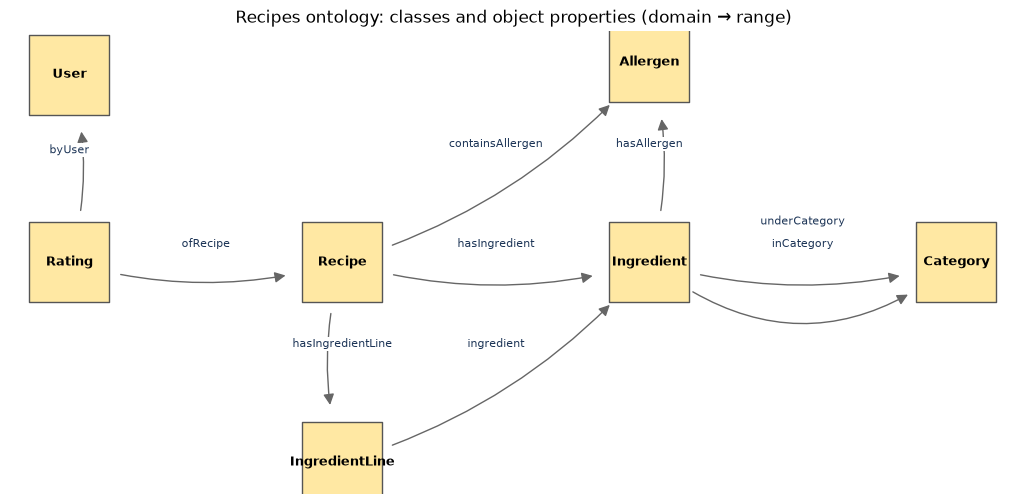

In [10]:
edges = properties[(properties.kind == 'ObjectProperty') & (properties.domain != '') & (properties.range != '')]
G = nx.MultiDiGraph()
for e in edges.itertuples():
    G.add_edge(e.domain.replace('rec:', ''), e.range.replace('rec:', ''), label=e.property.replace('rec:', ''))

pos = {'User': (0, 2.5), 'Rating': (0, 1), 'Recipe': (1.6, 1), 'IngredientLine': (1.6, -0.6),
       'Ingredient': (3.4, 1), 'Allergen': (3.4, 2.6), 'Category': (5.2, 1)}
fig, ax = plt.subplots(figsize=(13, 6))
nx.draw_networkx_nodes(G, pos, ax=ax, node_shape="s", node_size=3400, node_color='#ffe8a3', edgecolors='#555')
nx.draw_networkx_labels(G, pos, ax=ax, font_size=9, font_weight='bold')
seen = {}
for u, v, data in G.edges(data=True):
    k = seen.get((u, v), 0); seen[(u, v)] = k + 1
    rad = 0.15 + 0.25 * k
    nx.draw_networkx_edges(G, pos, ax=ax, edgelist=[(u, v)], node_size=3400, arrowsize=16,
                           edge_color='#666', connectionstyle=f'arc3,rad={rad}',
                           min_source_margin=38, min_target_margin=42)
    x, y = (pos[u][0] + pos[v][0]) / 2, (pos[u][1] + pos[v][1]) / 2
    ax.text(x, y + 0.12 + 0.18 * k, data['label'], fontsize=8, ha='center', color='#1d3557',
            bbox=dict(facecolor='white', edgecolor='none', pad=1))
ax.set_title('Recipes ontology: classes and object properties (domain → range)')
ax.axis('off'); plt.show()

`underCategory` and `inCategory` both run Ingredient → Category; one is stored and one is inferred.

### Step 5: check the data against the ontology

The ontology should cover every property and class the data uses. Anything used but **not declared** is a typo or a gap in the model. `FROM NAMED` lets one query look at both graphs:

In [11]:
CHECK = PREFIXES + f'''
SELECT ?kind ?term (COUNT(*) AS ?uses)
FROM NAMED <{DATA_GRAPH}> FROM NAMED <{MODEL_GRAPH}>
WHERE {{
  {{ GRAPH <{DATA_GRAPH}> {{ ?s ?term ?o }}  BIND("property" AS ?kind)  FILTER(?term != rdf:type) }}
  UNION
  {{ GRAPH <{DATA_GRAPH}> {{ ?s a ?term }}  BIND("class" AS ?kind) }}
  FILTER NOT EXISTS {{ GRAPH <{MODEL_GRAPH}> {{ ?term a ?declared }} }}
}}
GROUP BY ?kind ?term'''

def undeclared():
    return sparql.run_query(conn, CHECK)

print('Undeclared terms:', len(undeclared()))

Undeclared terms: 0


Nothing is undeclared. Now a **typo** sneaks in:

In [12]:
conn.update(f'''PREFIX rec: <http://example.org/recipes#> PREFIX recipe: <http://example.org/recipes/recipe/>
INSERT DATA {{ GRAPH <{DATA_GRAPH}> {{ recipe:pad-thai rec:prepMinuts 25 . }} }}''')
display(undeclared())
conn.update(f'''PREFIX rec: <http://example.org/recipes#> PREFIX recipe: <http://example.org/recipes/recipe/>
DELETE DATA {{ GRAPH <{DATA_GRAPH}> {{ recipe:pad-thai rec:prepMinuts 25 . }} }}''')

,kind,term,uses
0,property,http://example.org/recipes#prepMinuts,1


Next, check that the data **fits the domains and ranges**: every subject of a property with `rdfs:domain D` should be typed `D`, and every datatype value should have the declared datatype. This is a **closed-world** check we run ourselves. The reasoner would *infer* types instead of complaining.

In [13]:
sparql.run_query(conn, PREFIXES + f'''
SELECT ?problem ?property (COUNT(*) AS ?cases) (SAMPLE(?s) AS ?example)
FROM NAMED <{DATA_GRAPH}> FROM NAMED <{MODEL_GRAPH}>
WHERE {{
  {{
    GRAPH <{MODEL_GRAPH}> {{ ?property rdfs:domain ?domain }}
    GRAPH <{DATA_GRAPH}> {{ ?s ?property ?o  FILTER NOT EXISTS {{ ?s a ?domain }} }}
    BIND("subject not of the domain class" AS ?problem)
  }} UNION {{
    GRAPH <{MODEL_GRAPH}> {{ ?property a owl:DatatypeProperty ; rdfs:range ?range  FILTER(?range != rdf:langString) }}
    GRAPH <{DATA_GRAPH}> {{ ?s ?property ?o  FILTER(DATATYPE(?o) != ?range) }}
    BIND("value of the wrong datatype" AS ?problem)
  }}
}}
GROUP BY ?problem ?property''')

,problem,property,cases,example


Clean: the data matches the model. Chapter 9 generalizes these hand-written checks with SHACL.

### Step 6: register it as a named model

Stardog finds the ontology for reasoning through **named schemas** (the database option `reasoning.schemas`, Chapter 2). Each entry maps a name to a graph. The names are what Studio and Explorer list as **Models**. Stardog Designer creates the same kind of entry when you publish a model.

`src/kg/models.py` wraps this:

In [14]:
models.register_model(MODEL_NAME, MODEL_GRAPH)
pd.DataFrame([(name, ', '.join(graphs)) for name, graphs in models.list_models().items()], columns=['model', 'graphs'])

,model,graphs
0,Recipe_Basic,urn:Recipe_Basic:Recipe_Basic
1,Recipe_Python,urn:Recipe_Python:Recipe_Python
2,SupplyChain,urn:SupplyChain:SupplyChain
3,RecipeKG,urn:tutorial:ch07:model


`RecipeKG` sits next to any models you created in Designer or earlier projects. Registering changes only this one entry; the others are left untouched.

A first look at what the model makes possible. Nobody stored a single `rec:DairyRecipe` triple:

In [15]:
DAIRY = 'SELECT ?recipe { ?r a rec:DairyRecipe ; rec:name ?recipe  FILTER(lang(?recipe) = "en") } ORDER BY ?recipe'
print('without reasoning:', q(DAIRY).recipe.tolist())
print('with the RecipeKG model:', q(DAIRY, reasoning=True, schema=MODEL_NAME).recipe.tolist())

without reasoning: []


with the RecipeKG model: ['Chocolate Brownies', 'Margherita Pizza', 'Moules Marinieres', 'Pancakes', 'Pesto Pasta', 'Spaghetti Carbonara']


Chapter 8 explains exactly how that works, and what it costs.

### Step 7: look at it in Studio and Explorer

Set `CLEAN_UP = False` in 7.9 first, so the model stays in place.

- **Studio:** open your database's models and pick `RecipeKG` to browse the classes and properties with their labels and comments.
- **Explorer → Settings (⚙) → Model → RecipeKG** (the same dropdown where your Designer models appear). Search for "Pad Thai" and follow its links, then switch **Reasoning** on and off and compare what you can see.

## 7.8 Exercises

**Exercise 1.** Cuisine is a plain string today (`rec:cuisine "Thai"`). Sketch the ontology changes to make cuisines **resources**: a `rec:Cuisine` class, an object property `rec:hasCuisine`, and a `rec:region` value. Why is this better?

<details><summary>Solution</summary>

```turtle
rec:Cuisine a owl:Class ; rdfs:label "Cuisine"@en .
rec:hasCuisine a owl:ObjectProperty , owl:FunctionalProperty ;
    rdfs:domain rec:Recipe ; rdfs:range rec:Cuisine .
rec:region a owl:DatatypeProperty ; rdfs:domain rec:Cuisine ; rdfs:range xsd:string .
```
As resources, cuisines get labels in several languages, a region, and a hierarchy (Thai → Southeast Asian → Asian). The Chapter 6 `VALUES` mapping then becomes data. Typos also become visible, since `"Itallian"` would be an undeclared resource rather than just another string.
</details>

**Exercise 2.** Query the model graph: list all **functional** properties with their domain.

<details><summary>Solution</summary>

```python
q('SELECT ?p ?domain { ?p a owl:FunctionalProperty ; rdfs:domain ?domain } ORDER BY ?domain ?p', graphs=MODEL_GRAPH)
```
</details>

**Exercise 3.** Using the defined classes as a pattern, write a defined class `rec:GlutenRecipe`. Add it to a copy of the model in a new graph `f'{PREFIX}:model2'`, register that as `RecipeKG2`, and list gluten recipes with reasoning.

<details><summary>Solution</summary>

```python
extra = '''@prefix rec: <http://example.org/recipes#> . @prefix owl: <http://www.w3.org/2002/07/owl#> .
@prefix allergen: <http://example.org/recipes/allergen/> .
rec:GlutenRecipe a owl:Class ; owl:equivalentClass [ owl:intersectionOf ( rec:Recipe
  [ owl:onProperty rec:hasIngredient ; owl:someValuesFrom [ owl:onProperty rec:hasAllergen ; owl:hasValue allergen:gluten ] ] ) ] .'''
M2 = f'{PREFIX}:model2'
conn.update(f'COPY <{MODEL_GRAPH}> TO <{M2}>')
with client.transaction(conn):
    conn.add(stardog.content.Raw(extra.encode(), 'text/turtle'), graph_uri=M2)
models.register_model('RecipeKG2', M2)
print(q('SELECT ?r { ?r a rec:GlutenRecipe }', reasoning=True, schema='RecipeKG2'))
models.unregister_model('RecipeKG2')          # tidy up
```
</details>

**Exercise 4.** Why can't OWL define `rec:VeganRecipe` as "a recipe with no animal ingredient"? What would you use instead?

<details><summary>Solution</summary>

Under the open world assumption, missing information isn't false, so the reasoner can never be sure a recipe has **no** animal ingredient. There might be one that isn't recorded. Use a query with `FILTER NOT EXISTS` over the category hierarchy, or a Stardog rule (Chapter 8), which applies the check to the data as it is.
</details>

In [16]:
# your answers here

## 7.9 Clean up

Removes this chapter's graphs **and** unregisters the `RecipeKG` model, leaving your other models as they were. Set `CLEAN_UP = False` to keep exploring in Studio and Explorer.

In [17]:
CLEAN_UP = True

if CLEAN_UP:
    for name in ('RecipeKG', 'RecipeKG2'):
        models.unregister_model(name)
    graphs = sparql.run_query(conn, f'SELECT DISTINCT ?g {{ GRAPH ?g {{ ?s ?p ?o }} FILTER(STRSTARTS(STR(?g), "{PREFIX}")) }}').g.tolist()
    with client.transaction(conn):
        for g in graphs:
            conn.clear(graph_uri=g)
    print('Removed:', *graphs, sep='\n  ')
    print('Models now:', list(models.list_models()))
conn.close()

Removed:
  urn:tutorial:ch07:data
  urn:tutorial:ch07:model


Models now: ['Recipe_Basic', 'Recipe_Python', 'SupplyChain']


## Summary

- An **ontology** makes the meaning of the data explicit **as RDF**: classes, properties and rules, queryable and versioned like data.
- Start from the data: a **property profile** shows which classes use which properties with which values.
- **RDFS**: classes, sub-classes and sub-properties, **domain and range (which infer, not validate)**, labels and comments.
- **OWL**: object vs datatype properties, `inverseOf`, `FunctionalProperty`, `TransitiveProperty`, **property chains**, **disjointness**, and **defined classes** (`equivalentClass` + `someValuesFrom` / `hasValue`).
- **Design**: classes for what things are, taxonomies (SKOS) for how people classify them; label and comment everything; reuse standards. OWL can't express "no …", checks, or arithmetic. Use queries, rules (Ch 8) and SHACL (Ch 9) for those.
- **Profiles**: Stardog reasons at query time; the default **SL** level handles everything in our ontology.
- Keep the model in **its own named graph**, check the data against it, and **register it as a named model** (`models.register_model`) for reasoning, Studio and Explorer.

**Next: Chapter 8, Reasoning.** Inferred types, inverse and transitive properties, property chains and defined classes in action, Stardog rules for "vegan" and "quick", explanations of inferences, and what reasoning costs.